# <div dir= 'rtl'>تمرین اول درس یادگیری عمیق  سینا ملاابراهیمی </div>

# <div dir= 'rtl'>کتابخانه های لازم و تنظیم استایل </div>

In [31]:
import numpy as np 
import pandas as pd 
import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# <div dir= 'rtl'>تعریف تابع ساخت داده ها</div>

In [32]:
def  generate_data (true_func, X_range = (0,1), n_samples=100, random_x = True, noise_std = 0.0 ):
    """
        تولید داده‌های مصنوعی برای مجموعه‌های آموزشی و تست
    
    ورودی‌ها:
    true_func : callable
        تابع ریاضی که رابطه بین x و y را مشخص می‌کند.

    n_samples : int
        تعداد نمونه‌ها.

    x_range : tuple (min, max)
        بازه مقادیر x.

    noise_std : float
        انحراف معیار نویز گاوسی افزوده به داده‌ها.

    random_x : bool
        اگر True باشد، مقادیر x به صورت تصادفی در x_range نمونه‌برداری می‌شوند.
        اگر False باشد، xها به‌طور یکنواخت در سراسر x_range فاصله‌گذاری می‌شوند.
    
    خروجی‌ها:
    X : ndarray
        آرایه‌ای از مقادیر تولیدشده x

    y : ndarray
        آرایه‌ای از مقادیر y متناظر با x (با نویز اگر noise_std > 0)
        
    
    """
    X_min, X_max = X_range
    
    if random_x:
        X = np.random.uniform(X_min,X_max,n_samples)
    else:
        X = np.linspace(X_min,X_max,n_samples)
    
    y = true_func(X) 

    if noise_std > 0 :
        y = y + np.random.normal(0,noise_std, y.shape)

    return X,y

# <div dir= 'rtl'>تعریف رابطه پنهان (واقعی داده ها)</div>

In [33]:
def underlying_func(X):
    return 0.5*X**3 + X**2 + 2*X + 5
X_test,y_test = generate_data(underlying_func,X_range=(-3,3),n_samples=20,random_x=False,noise_std=0)


# <div dir= 'rtl'>رسم رابطه  پنهان (واقعی) </div>

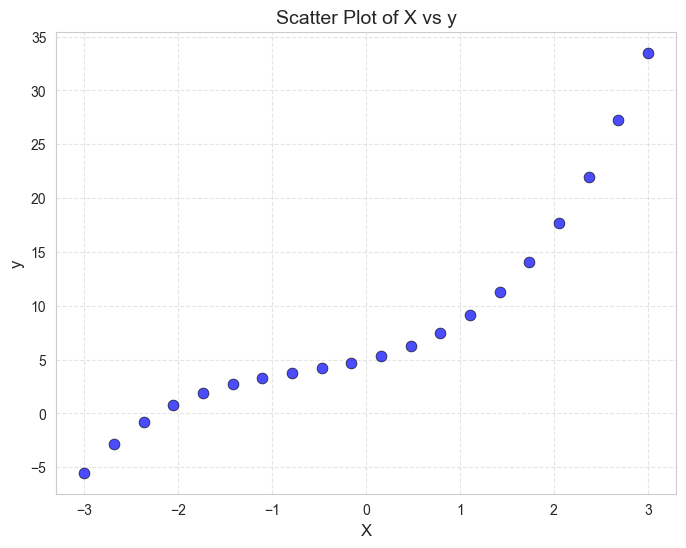

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_test, y=y_test, color='blue', s=60, alpha=0.7, edgecolor='k')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Scatter Plot of X vs y', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# <div dir= 'rtl'>آموزش مدل با استفاده از کتابخانه <code>sklearn</code></div>

In [35]:
bias_s_list = []
variance_list = []
degrees = [1,2,3,4,5,6]
for degree in degrees:
    predictions = []
    for i in range(1,51):
        x_train, y_train = generate_data(underlying_func,X_range=(-5,5),n_samples=20,random_x=True,noise_std=15)
        x_train = x_train.reshape(-1,1)

        poly = PolynomialFeatures(degree=degree)
        x_train_ploy = poly.fit_transform(x_train)
        X_test_ploy = poly.transform(X_test.reshape(-1,1))

        model = LinearRegression()
        model.fit(x_train_ploy,y_train)

        y_pred = model.predict(X_test_ploy)
        predictions.append(y_pred)
    predictions = np.array(predictions)
    mean_pred = predictions.mean(axis=0)
    bias_s = np.mean((y_test-mean_pred)**2)
    variance = np.mean(predictions.var(axis=0))
    bias_s_list.append(bias_s)
    variance_list.append(variance)

# <div dir= 'rtl'>محاسبه خطای کل </div>

In [36]:
total_error = np.mean((predictions - y_test)**2)

# <div dir= 'rtl'>رسم نمودار واریانس ، اریبی و خطای کل </div>

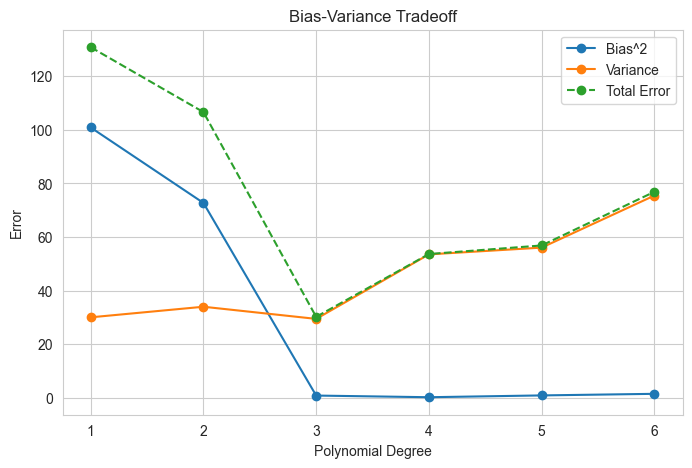

In [37]:
plt.figure(figsize=(8,5))
plt.plot(degrees, bias_s_list, marker='o', label='Bias^2')
plt.plot(degrees, variance_list, marker='o', label='Variance')
plt.plot(degrees, np.array(bias_s_list)+np.array(variance_list), marker='o', linestyle='--', label='Total Error')
plt.xlabel('Polynomial Degree')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.show()

# <div dir= 'rtl'>تعریف و رسم رابطه خطی</div>

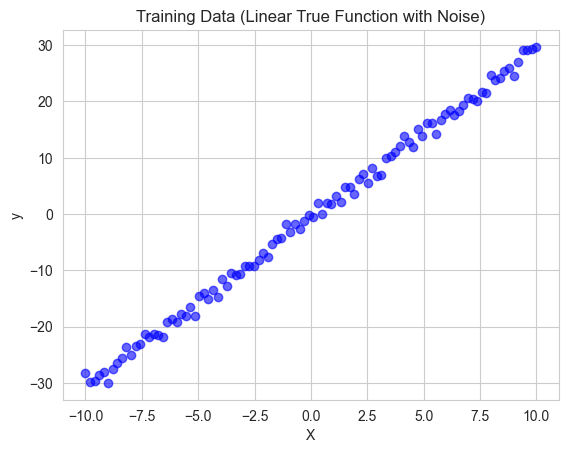

In [38]:
def true_func_1(x):
    return 3*x- 0.5
x_train_1,y_train_1 = generate_data(true_func_1,X_range=(-10,10),n_samples=100,random_x=False,noise_std=1)
plt.scatter(x_train_1, y_train_1, color='blue', alpha=0.6)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Training Data (Linear True Function with Noise)")
plt.show()

# <div dir= 'rtl'>تعریف مدل خطی </div>

In [39]:
def h_w (X,w0,w1):
    return w0 + w1*X

# <div dir= 'rtl'>تعریف تابع هزینه</div>

In [40]:
def c_c (X,Y,w0,w1):
    m = len(Y)
    y_pred = h_w(X, w0, w1)
    cost = (1/m)*(np.sum((y_pred-Y)**2))
    return cost

# <div dir= 'rtl'>تعریف تابع <code>BGD</code></div>

In [41]:
def BGD(X,y,LR = 0.01 , epochs = 500):
    m = len(y)
    w0 = 0.0
    w1 = 0.0
    w0_list = []
    w1_list = []
    cost_list = []

    for epoch in range(epochs):
        y_pred = h_w(X, w0, w1 )
        diff = y_pred-y
        diff_w0 = (1/m) * np.sum(diff)
        diff_w1 = (1/m) * np.sum(diff * X)
        w0 = w0 - LR * diff_w0
        w1 = w1 - LR * diff_w1
        w0_list.append(w0)
        w1_list.append(w1)
        cost_list.append(c_c(X,y,w0,w1))
    return w0, w1, w0_list, w1_list, cost_list

# <div dir= 'rtl'>اعمال تابع <code>BGD</code></div>

In [42]:
w0, w1, w0_list, w1_list, cost_list = BGD(x_train_1,y_train_1,0.0001,500)
print('w0 : ', w0)
print('w1 : ', w1)

w0 :  -0.02953922663482835
w1 :  2.454950458702832


# <div dir= 'rtl'>رسم نمودار تابع هزینه در برابر تکرار (هدف نشان دادن همگرایی و عملکرد تابع <code>BGD</code>)</div>

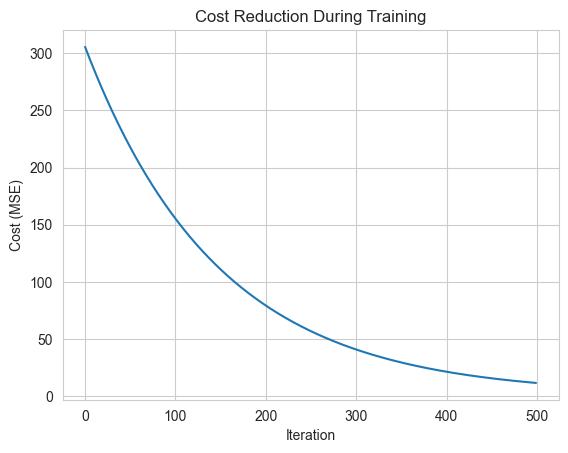

In [43]:
plt.plot(cost_list)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Cost Reduction During Training")
plt.show()


# <div dir= 'rtl'>رسم عملکرد مدل با افزایش تکرار</div>

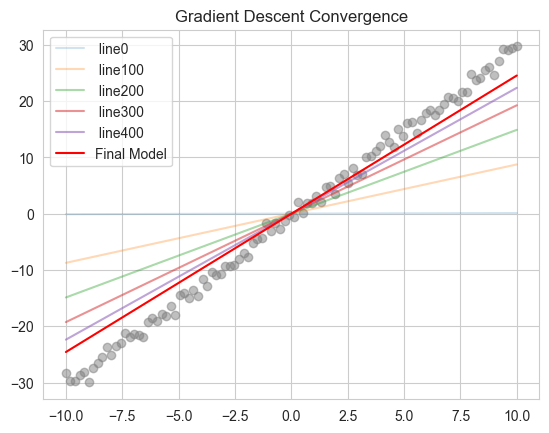

In [44]:
plt.scatter(x_train_1, y_train_1, color='gray', alpha=0.5)

x_line = np.linspace(-10, 10, 100)

for i in range(0, len(w0_list), 100):
    y_line = w0_list[i] + w1_list[i] * x_line
    plt.plot(x_line, y_line, alpha=0.2+(i*0.001),label = f' line{i}')

plt.plot(x_line, w0 + w1 * x_line, color='red', label='Final Model')
plt.legend()
plt.title("Gradient Descent Convergence")
plt.show()


# <div dir= 'rtl'>رسم تابع هزینه در برابر تکرار بعد از استاندارد سازی</div>

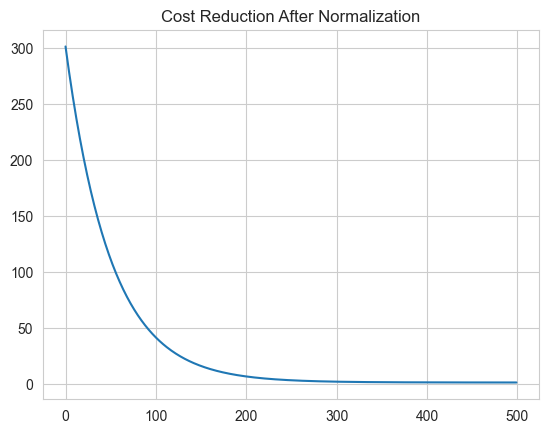

In [45]:
X_mean = np.mean(x_train_1)
X_std = np.std(x_train_1)
X_norm = (x_train_1 - X_mean) / X_std

w0_n, w1_n, _, _, cost_norm = BGD(X_norm, y_train_1,0.01,500)
plt.plot(cost_norm)
plt.title("Cost Reduction After Normalization")
plt.show()


# <div dir= 'rtl'>رسم نمودار سه بعدی وزن ها در برابر تابع هزینه</div>

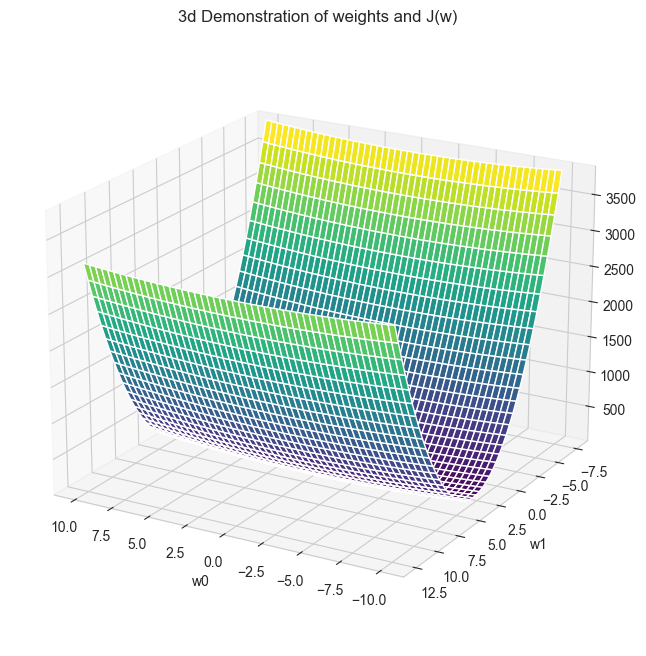

In [46]:
w0_vals = np.linspace(w0-10, w0+10, 50)
w1_vals = np.linspace(w1-10, w1+10, 50)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
J_vals = np.zeros(W0.shape)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        J_vals[i, j] = c_c(x_train_1, y_train_1, W0[i, j], W1[i, j])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0, W1, J_vals, cmap='viridis')
ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_zlabel('J(w0, w1)', fontsize=14, labelpad=12)
ax.set_zlim(min(J_vals.flatten()), max(J_vals.flatten()))
ax.set_title('3d Demonstration of weights and J(w)')
ax.view_init(elev=20, azim=120)
plt.show()

# <div dir= 'rtl'>رسم نمودار وزن ها در برابر لگاریتم تابع هزینه</div>

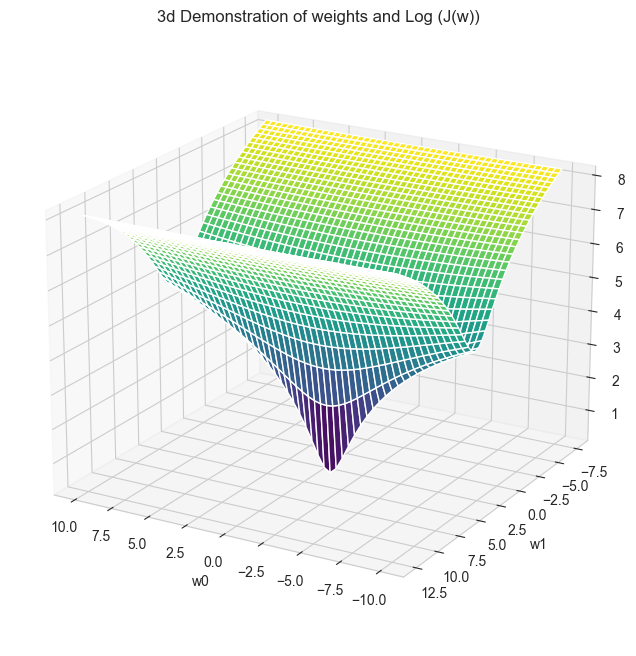

In [47]:
w0_vals = np.linspace(w0-10, w0+10, 50)
w1_vals = np.linspace(w1-10, w1+10, 50)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
log_J_vals = np.zeros(W0.shape)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        log_J_vals[i, j] = np.log(c_c(x_train_1, y_train_1, W0[i, j], W1[i, j]))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0, W1, log_J_vals, cmap='viridis')
ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_zlabel('J(w0, w1)', fontsize=14, labelpad=12)
ax.set_zlim(min(log_J_vals.flatten()), max(log_J_vals.flatten()))
ax.set_title('3d Demonstration of weights and Log (J(w))')
ax.view_init(elev=20, azim=120)
plt.show()

# <div dir= 'rtl'>رسم نمودار مسیر گرادیان روی لگاریتم تابع هزینه در برابر تکرار  </div>

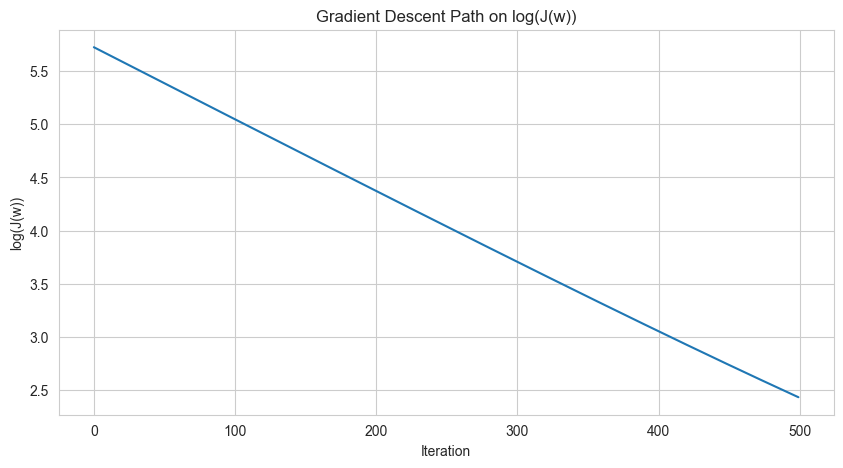

In [48]:
log_cost = np.log(cost_list)
plt.figure(figsize=(10,5))
plt.plot(log_cost)
plt.xlabel("Iteration")
plt.ylabel("log(J(w))")
plt.title("Gradient Descent Path on log(J(w))")
plt.grid(True)
plt.show()

# <div dir= 'rtl'>پیاده سازی دستی (امتیازی)</div>

In [49]:
def polynomial_features (X,degree):
    """
    X: array-like, shape (m,) یا (m, 1)
    
    degree: int، درجه چندجمله‌ای

    خروجی:
        X_poly: شکل (m, degree+1)
        
        همه یک :ستون ۰
        
        ستون‌های بعدی: X^1, X^2, ..., X^degree
    """
    X = np.array(X)
    if X.ndim == 1:
        X = X.reshape(-1,1)
    m = X.shape[0]
    X_poly = np.ones((m,degree+1))
    for d in range(1,degree + 1):
            X_poly[:,d] = (X[:,0] ** d)
    return X_poly 

In [50]:
X = np.array([4, 5])
degree = 3
X_poly = polynomial_features(X, degree)
print(X_poly)

[[  1.   4.  16.  64.]
 [  1.   5.  25. 125.]]


In [51]:
def predict(X,w):
    """
    X: ماتریس ویژگی‌ها، شکل (m, degree+1)
    
    w: وزن‌ها، شکل (degree+1,)

    خروجی: y_pred با شکل (m,)
    """
    return X @ w

In [52]:
def compute_cost(X_poly, y, w):
    """
    X_poly: شکل (m, n)
    y: شکل (m,)
    w: شکل (n,)
    """
    m = len(y)
    y_pred = predict(X_poly, w)
    error = y_pred - y
    cost = (1 / (2 * m)) * np.sum(error ** 2)
    return cost

In [53]:
def gradient_descent(X, y, w_init, lr, n_iters, store_weights=True):
    """
    X:  (m, d)
    y:  (m, )
    w_init: (d, )
    lr: learning rate
    n_iters: number of iterations
    """
    m, d = X.shape
    w = w_init.copy()
    if store_weights:
        w_history = np.zeros((n_iters, d))
    for it in range(n_iters):
        y_pred = X @ w
        error = y_pred - y
        grad = (1/m) * (X.T @ error)
        w = w - lr * grad
        if store_weights:
            w_history[it] = w
    if store_weights:
        return w, w_history
    else:
        return w

In [54]:
def normalize_features(X, mean=None, std=None):
    
    X_no_bias = X[:,1:]

    if mean is None:
        mean = X_no_bias.mean(axis=0)

    if std is None:
        std = X_no_bias.std(axis=0) + 1e-8

    X_no_bias = (X_no_bias - mean) / std

    X_norm = np.c_[np.ones(X.shape[0]), X_no_bias]

    return X_norm, mean, std

In [55]:
def run_simulation(degree, lr=0.03, n_iters=5000):
    preds = []

    for s in range(50):
        x_train, y_train = generate_data(underlying_func,X_range=(-5,5),n_samples=20,random_x=True,noise_std=15)
        X_poly = polynomial_features(x_train, degree)
        X_test_poly = polynomial_features(X_test.reshape(-1,1), degree)
        X_poly, mean, std = normalize_features(X_poly)
        X_test_poly, _, _ = normalize_features(X_test_poly, mean, std)
        w_init = np.zeros(degree+1)
        w, _ = gradient_descent(X_poly, y_train, w_init, lr, n_iters)
        y_pred = predict(X_test_poly, w)
        preds.append(y_pred)

    preds = np.array(preds)      
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - y_test)**2)
    variance = np.mean(np.var(preds, axis=0))
    return bias2, variance


In [56]:
bias_list = []
var_list = []
total_error_list = []
for d in range(1, 7):
    bias2, var = run_simulation(d)
    total_error = (bias2) + var
    bias_list.append(bias2)
    var_list.append(var)
    total_error_list.append(total_error)
    print(f"degree {d}: bias^2 = {bias2:.4f}   variance = {var:.4f}     Total Error = {total_error}")


degree 1: bias^2 = 114.5885   variance = 33.7192     Total Error = 148.3077505530115
degree 2: bias^2 = 72.9523   variance = 39.6671     Total Error = 112.6194873962139
degree 3: bias^2 = 0.2199   variance = 38.6362     Total Error = 38.85608657718787
degree 4: bias^2 = 0.0450   variance = 37.4821     Total Error = 37.527049236507196
degree 5: bias^2 = 0.6630   variance = 43.9818     Total Error = 44.644770592822425
degree 6: bias^2 = 1.5306   variance = 45.1065     Total Error = 46.637136623728466


# <div dir= 'rtl'>رسم جدول اریبی ، واریانس و خطای کل </div>

In [57]:
data = {'degree':degrees,'bias_s':bias_list,'variance':var_list,'total_error':total_error_list}
df = pd.DataFrame(data)
df.set_index('degree',inplace=True) 
df

,bias_s,variance,total_error
degree,,,
1,114.588550,33.719201,148.307751
2,72.952346,39.667141,112.619487
3,0.219853,38.636234,38.856087
4,0.044988,37.482061,37.527049
5,0.663018,43.981753,44.644771
6,1.530626,45.106510,46.637137


# <div dir= 'rtl'>رسم نمودار اریبی ، واریانس و خطای کل </div>

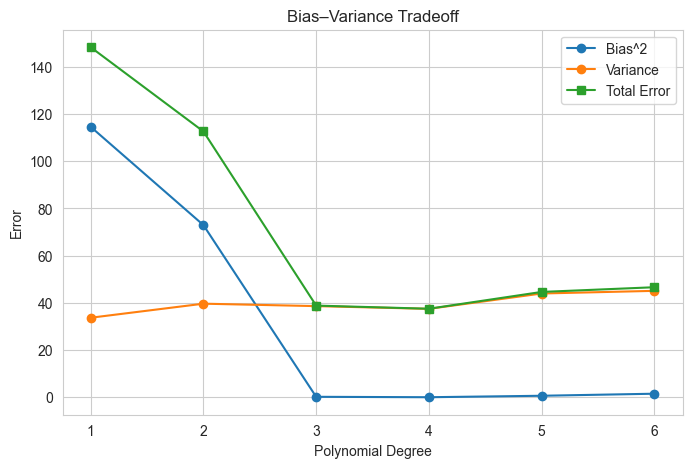

In [58]:
degrees = np.arange(1, 7)
plt.figure(figsize=(8,5))
plt.plot(degrees, bias_list, '-o', label='Bias^2')
plt.plot(degrees, var_list, '-o', label='Variance')
plt.plot(degrees, np.array(bias_list)+np.array(var_list), '-s', label='Total Error')
plt.xlabel("Polynomial Degree")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff")
plt.grid(True)
plt.legend()
plt.show()